In [1]:
# This notebook shows the implementation of a trigram model (part of makemore's exercise)

In [2]:
words = open("names.txt", "r").read().splitlines()

In [3]:
min(len(word) for word in words)

2

In [4]:
max(len(word) for word in words)

15

In [5]:
# getting all the charecters that are unique in the names dataset
chars = list(sorted(set("".join(words))))
# each characters associated with an index to later create a probability matrix out of it.
stoi = {s:i+1 for i,s in enumerate(chars)}
# add . as it's a special token used to denote start and end of word.
stoi['.'] = 0
# reverse stoi list to get i that maps to its respective s
itos = {i:s for s,i in stoi.items()}

In [6]:
len(chars)

26

In [7]:
import torch

In [19]:
pmatrx = torch.zeros((27, 27, 27), dtype=torch.int32)

In [20]:
# padding with tokens to indicate start and end words.
for w in words:
    char = ['.'] + list(w) + ['.']
    for c1, c2, c3 in zip(char, char[1:], char[2:]):
        ix1 = stoi[c1]
        ix2 = stoi[c2]
        ix3 = stoi[c3]
        pmatrx[ix1, ix2, ix3] += 1

In [21]:
import matplotlib.pyplot as plt
%matplotlib inline

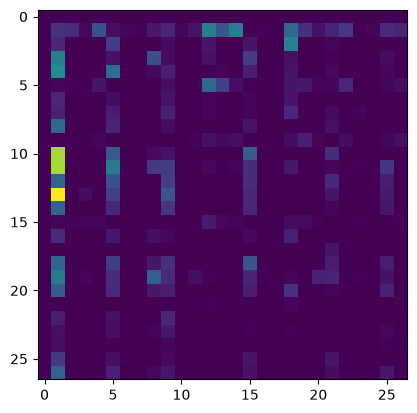

In [25]:
plt.imshow(pmatrx[0])

In [10]:
# neural network approach